In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import warnings
warnings.filterwarnings('ignore')


In [ ]:
data=pd.read_csv('tech_mental_health_burnout.csv')

In [ ]:
data

,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,...,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,...,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,...,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,...,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,...,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,54,Female,DevOps,6.8,Mid-size,Remote,41.0,4.0,5.0,3,...,12.0,2,7.3,0,6.9,2.7,3.2,1.2,Low,0
149996,52,Male,Software Engineer,5.7,Startup,Hybrid,42.0,4.0,5.0,2,...,6.8,1,3.2,0,4.6,5.3,3.3,1.1,Low,0
149997,36,Male,Backend Developer,2.2,Mid-size,Hybrid,38.0,6.0,2.0,0,...,8.9,5,8.5,0,7.9,4.2,3.9,2.8,Low,0
149998,35,Male,Frontend Developer,3.7,Large,Hybrid,41.0,9.0,6.0,5,...,10.1,3,5.6,1,5.7,5.4,3.4,1.5,Low,0


In [ ]:
df=data.copy()

In [ ]:
# kmeans clustering

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
df1=pd.get_dummies(df)

In [ ]:
cat_cols=df.select_dtypes('object').columns

In [ ]:
x=df1.drop(columns=['burnout_score'])

In [ ]:
y=df['burnout_score']

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
ss=StandardScaler()

In [ ]:
x=ss.fit_transform(x)

In [ ]:
wcss=[]
for i in range(1,13):
    km=KMeans(n_clusters=i)
    km.fit_predict(x)
    wcss.append(km.inertia_)


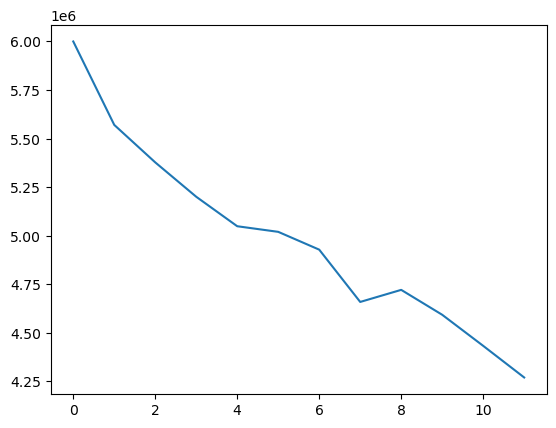

In [ ]:
plt.plot(wcss)

In [ ]:
km=KMeans(n_clusters=3)

In [ ]:
df['cluster']=km.fit_predict(x)

In [ ]:
df['cluster']

0         0
1         1
2         0
3         1
4         2
         ..
149995    0
149996    2
149997    2
149998    2
149999    0
Name: cluster, Length: 150000, dtype: int32

In [ ]:
zero=df[df['cluster']==0]

In [ ]:
one=df[df['cluster']==1]

In [ ]:
two=df[df['cluster']==2]

In [ ]:
df.groupby('cluster')['burnout_score'].mean()

cluster
0    1.323515
1    4.255169
2    2.254741
Name: burnout_score, dtype: float64

In [ ]:
df.columns

Index(['age', 'gender', 'job_role', 'experience_years', 'company_size',
       'work_mode', 'work_hours_per_week', 'overtime_hours',
       'meetings_per_day', 'deadlines_missed', 'job_satisfaction',
       'manager_support', 'work_life_balance', 'sleep_hours',
       'physical_activity_days', 'screen_time_hours', 'caffeine_intake',
       'social_support_score', 'has_therapy', 'stress_level', 'anxiety_score',
       'depression_score', 'burnout_score', 'burnout_level',
       'seeks_professional_help', 'cluster'],
      dtype='object')

In [ ]:
df.groupby('cluster')[['stress_level', 'anxiety_score','depression_score', 'burnout_score']].mean()

,stress_level,anxiety_score,depression_score,burnout_score
cluster,,,,
0,4.740076,3.608622,2.140688,1.323515
1,7.544946,5.697084,4.394173,4.255169
2,6.254759,5.031719,3.608333,2.254741


In [ ]:
df.groupby('cluster')[['age','experience_years']].mean()

,age,experience_years
cluster,,
0,37.993321,5.058065
1,37.903482,5.063237
2,38.086204,5.050102


In [ ]:
#What percentage of employees fall into each behavioral segment?

In [ ]:
df['cluster'].value_counts()/df.shape[0]*100

cluster
2    46.324000
0    41.422667
1    12.253333
Name: count, dtype: float64

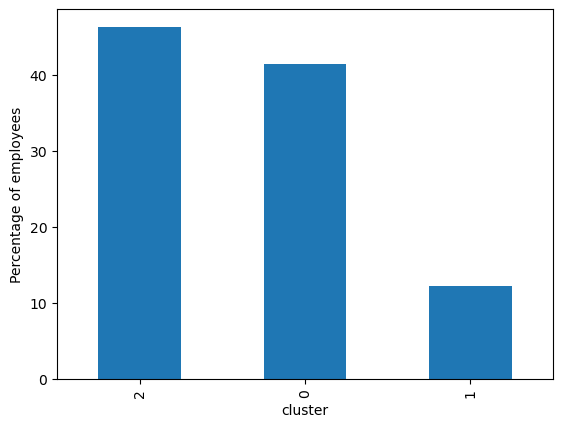

In [ ]:
(df['cluster'].value_counts()/df.shape[0]*100).plot(kind='bar')
plt.ylabel('Percentage of employees')
plt.show()

In [ ]:
#PCA

In [ ]:
df.shape

(150000, 26)

In [ ]:
df1=df.copy()

In [ ]:
df1=pd.get_dummies(df1)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x=df1.drop(columns=['cluster'])

In [ ]:
y=df1['cluster']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
ss=StandardScaler()

In [ ]:
x_train_trans=ss.fit_transform(x_train)

In [ ]:
x_train.shape

(120000, 41)

In [ ]:
x_test_trans=ss.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr=LogisticRegression(multi_class='multinomial')

In [ ]:
lr.fit(x_train_trans,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [ ]:
pred_lr=lr.predict(x_test_trans)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,pred_lr)

0.9994333333333333

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca=PCA(n_components=29)

In [ ]:
x_train_pca=pca.fit_transform(x_train_trans)

In [ ]:
x_test_pca=pca.transform(x_test_trans)

In [ ]:
lr.fit(x_train_pca,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [ ]:
pca_pred=lr.predict(x_test_pca)

In [ ]:
accuracy_score(y_test,pca_pred)

0.9750333333333333

In [ ]:
x_train_pca.shape

(120000, 29)

In [ ]:
pca.explained_variance_ratio_

array([0.11316263, 0.04650792, 0.03915195, 0.03492611, 0.03406964,
       0.03258939, 0.03252577, 0.03249262, 0.03137744, 0.03043166,
       0.0284484 , 0.02776327, 0.02774789, 0.02748402, 0.02725909,
       0.02674168, 0.02657373, 0.02607306, 0.02484969, 0.02472392,
       0.02458589, 0.02454134, 0.02442308, 0.0243998 , 0.02434539,
       0.02433248, 0.02426745, 0.02419315, 0.0241033 ])

In [ ]:
r=0
for i in pca.explained_variance_ratio_:
    r+=i
    print(r)

0.11316263456926368
0.15967055055746027
0.19882250056377224
0.23374861499785288
0.26781825580109614
0.30040764809323645
0.3329334210785606
0.3654260368166693
0.39680348081640754
0.42723514500845655
0.45568354425682395
0.48344681644377174
0.5111947072307664
0.5386787270184636
0.5659378120410938
0.5926794936480565
0.6192532220466356
0.6453262841359989
0.6701759762508466
0.6948998978730478
0.719485784603662
0.744027126170888
0.768450210750686
0.7928500151991538
0.8171954100412963
0.8415278944548754
0.8657953399547855
0.8899884875900299
0.9140917853510531


In [ ]:
a=pd.Series(pca.explained_variance_ratio_.cumsum())

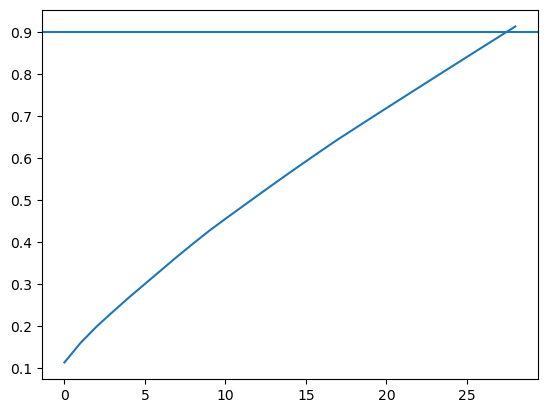

In [ ]:
plt.plot(a)
plt.axhline(0.9)

In [ ]:
# PCA (n_components=2)

In [ ]:
pca_2=PCA(n_components=2)

In [ ]:
x=ss.fit_transform(x)

In [ ]:
pca_df=pca_2.fit_transform(x)

In [ ]:
df2=pd.DataFrame(data=pca_df,columns=['col1','col2'])

In [ ]:
df2['cluster']=df['cluster']

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


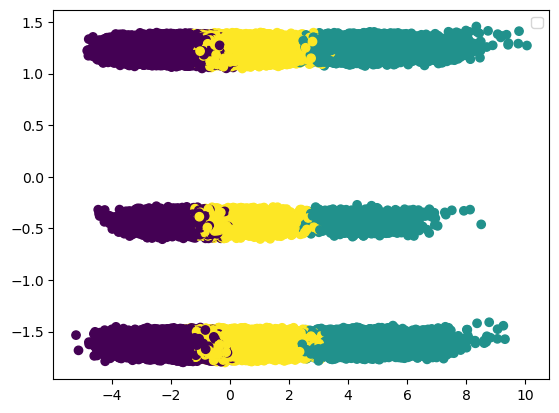

In [ ]:
plt.scatter(df2['col1'],df2['col2'],c=df2['cluster'])
plt.legend()

In [ ]:
# analysis

In [ ]:
scores=['stress_level', 'anxiety_score',
       'depression_score', 'burnout_score']

In [ ]:
df.groupby('cluster')[scores].mean()

,stress_level,anxiety_score,depression_score,burnout_score
cluster,,,,
0,4.740076,3.608622,2.140688,1.323515
1,7.544946,5.697084,4.394173,4.255169
2,6.254759,5.031719,3.608333,2.254741


<Axes: xlabel='cluster'>

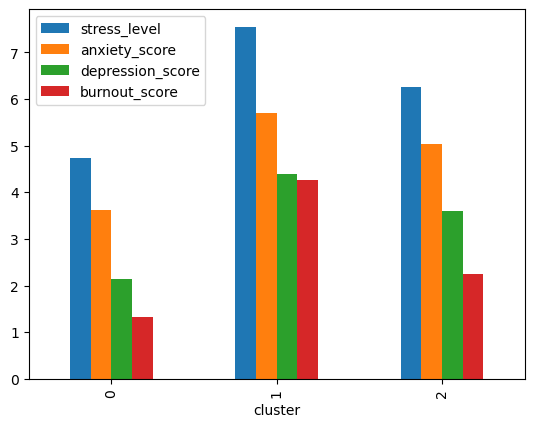

In [ ]:
df.groupby('cluster')[scores].mean().plot(kind='bar')

In [ ]:
df.groupby('cluster')['job_satisfaction'].mean()

cluster
0    5.809377
1    5.368237
2    5.258746
Name: job_satisfaction, dtype: float64

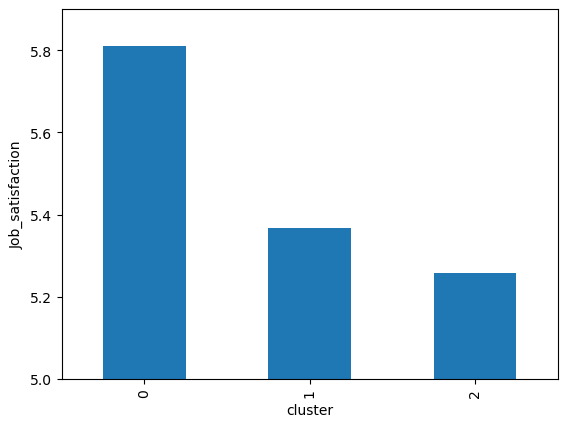

In [ ]:
df.groupby('cluster')['job_satisfaction'].mean().plot(kind='bar',ylim=(5.0,5.9))
plt.ylabel('Job_satisfaction')
plt.show()